# Libraries

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.cluster import KMeans , DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load Data & Preprocess

In [3]:
data = load_wine()

df = pd.DataFrame(data.data, columns=data.feature_names)
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [4]:
df.shape

(178, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [6]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [7]:
df.isna().sum()

,0
alcohol,0
malic_acid,0
ash,0
alcalinity_of_ash,0
magnesium,0
total_phenols,0
flavanoids,0
nonflavanoid_phenols,0
proanthocyanins,0
color_intensity,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
x_scaled = StandardScaler().fit_transform(df)
x_pca = PCA(n_components=5).fit_transform(x_scaled)

# KMean Before & After PCA(5)

Text(0, 0.5, 'Inertia')

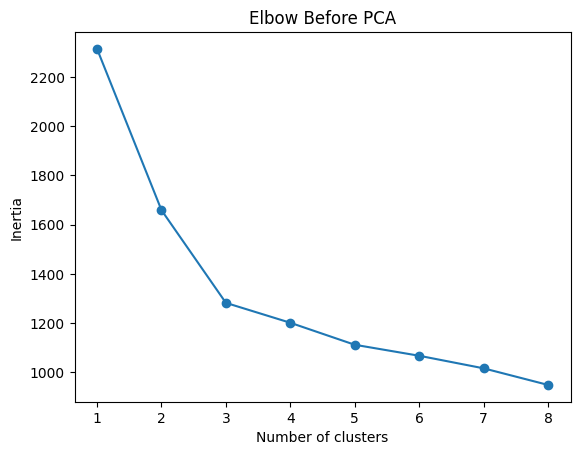

In [10]:
inertia = []
for k in range(1,9):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(x_scaled)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,9), inertia , marker='o')
plt.title('Elbow Before PCA')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

Text(0, 0.5, 'Inertia')

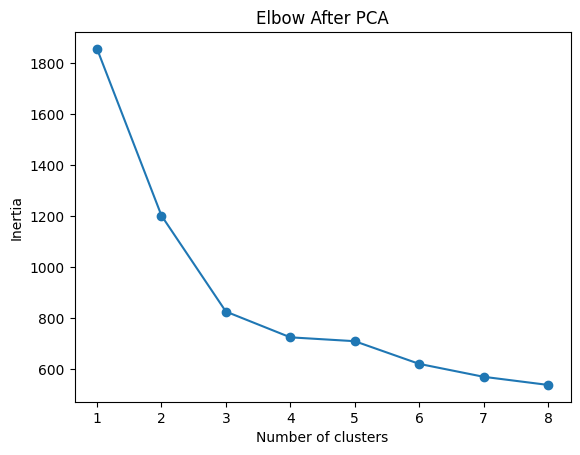

In [11]:
inertia = []
for k in range(1,9):
  kmeans = KMeans(n_clusters=k)
  kmeans.fit(x_pca)
  inertia.append(kmeans.inertia_)

plt.plot(range(1,9), inertia , marker='o')
plt.title('Elbow After PCA')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')

In [12]:
model1 = KMeans(n_clusters=3, random_state=42)
df['Cluter_B'] = model1.fit_predict(x_scaled)

In [13]:
print('Before PCA: ', silhouette_score(x_scaled, df['Cluter_B']))

Before PCA:  0.2848589191898987


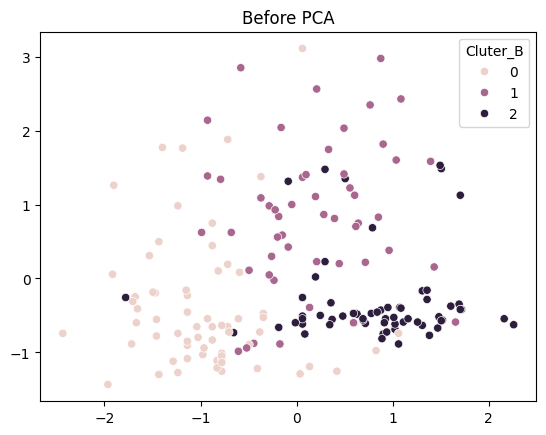

In [14]:
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=df['Cluter_B'])
plt.title('Before PCA')
plt.show()

In [15]:
model2 = KMeans(n_clusters=3, random_state=42)
df['Cluter_A'] = model2.fit_predict(x_pca)

In [16]:
print('After PCA: ', silhouette_score(x_pca, df['Cluter_A']))

After PCA:  0.36907631946992303


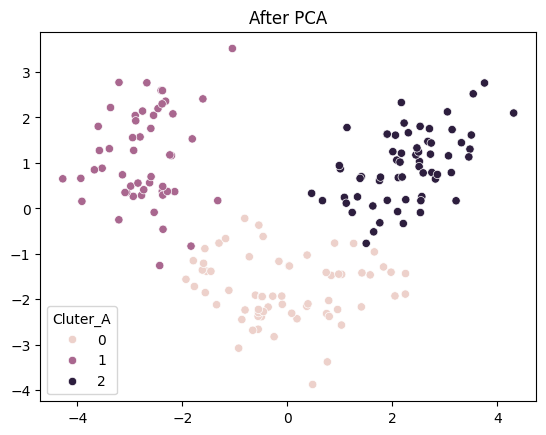

In [17]:
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=df['Cluter_A'])
plt.title('After PCA')
plt.show()

In [18]:
pca_model_for_variance = PCA(n_components=5)
pca_model_for_variance.fit(x_scaled)
print(f"Variance explained by 5 components: {pca_model_for_variance.explained_variance_ratio_.sum():.2%}")

Variance explained by 5 components: 80.16%


## summary

- After PCA the results of silloute score were better ever in the visulaiztion :



1.   Before PCA: 0.28
2.   After PCA: 0.36


- We kept 80% of the informations after PCA

# Bonus

In [19]:
db = DBSCAN(eps=1.6, min_samples=6)
df['Cluter_DB'] = db.fit_predict(x_scaled)

In [20]:
s = silhouette_score(x_scaled, df['Cluter_DB'])
print('Silhouette Score: ', s)

Silhouette Score:  -0.016182011264898974


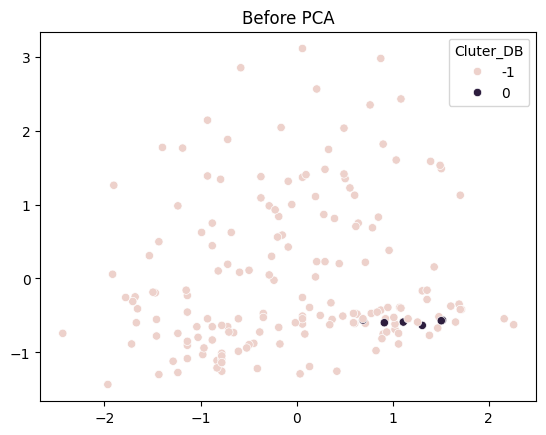

In [21]:
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=df['Cluter_DB'])
plt.title('Before PCA')
plt.show()

In [22]:
db = DBSCAN(eps=1.6, min_samples=6)
df['Cluter_DBC'] = db.fit_predict(x_pca)

In [23]:
sc = silhouette_score(x_scaled, df['Cluter_DBC'])
print('Silhouette Score: ', sc)

Silhouette Score:  0.1004571676406537


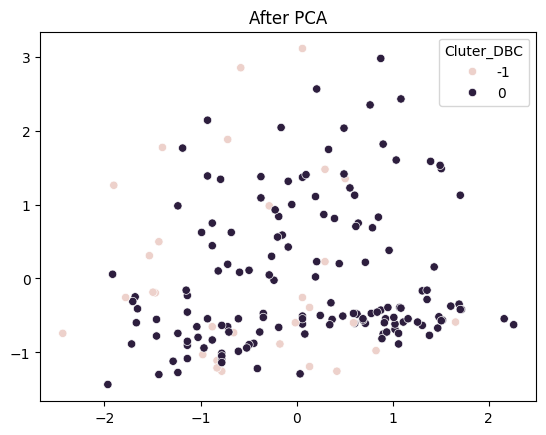

In [24]:
sns.scatterplot(x=x_scaled[:,0], y=x_scaled[:,1], hue=df['Cluter_DBC'])
plt.title('After PCA')
plt.show()

- We already tried different PCA in different notebooks but about the algorithm the DBSCAN becomes better after PCA but if we compare it to the KMean the KMean was better than DBSCAN before and after pca

# Analysis

- How did PCA affect clustering results?

- Did visualization become clearer?

- Did you lose important information?

- Which approach is better and why?

## Answer

1. The results were better and the visulaization after it were clearer compared to the 13 dimentions before

2. Yes as i mentiond in the answer before the visualization becomes clearer and more logical

3. Due to the improvment in the Silhouette score and keeping 80% of the variance we have so i think that we kept the important informations and the 20% that we lost is mostly noise

4. The PCA approach is better because it turns it to 2D and preserves the important data so the visualiztion becomes clearer and the clustring results becomes better also that's why i prefer PCA